In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('slip_1.csv')
print(dataset.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [3]:
from sklearn.impute import SimpleImputer
c_c=['Gender','Married','Dependents','Self_Employed']
n_c=['LoanAmount','Loan_Amount_Term','Credit_History']
c_i=SimpleImputer(missing_values=np.nan,strategy='most_frequent')
n_i=SimpleImputer(missing_values=np.nan,strategy='mean')

dataset[c_c]=c_i.fit_transform(dataset[c_c])
dataset[n_c]=n_i.fit_transform(dataset[n_c])


In [4]:
print(dataset.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [5]:
X=dataset.iloc[:,1:-1].values
y=dataset.iloc[:,-1].values

In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [7]:
print(y)

[1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 0
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 0
 1 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1
 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1
 1 0 1 1 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1 0 1 0 1
 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0
 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 0 1 1
 1 1 0 0 0 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0
 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1 0 1 1
 1 0 0 0 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 1
 1 1 1 1 1 0 0 1 0 1 1 1 

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
c=ColumnTransformer(transformers=[('encoder',OneHotEncoder(sparse_output=False),[0,1,2,3,4,10])],remainder='passthrough')
X=c.fit_transform(X)

print(X)

[[0.0 1.0 1.0 ... 146.41216216216216 360.0 1.0]
 [0.0 1.0 0.0 ... 128.0 360.0 1.0]
 [0.0 1.0 0.0 ... 66.0 360.0 1.0]
 ...
 [0.0 1.0 0.0 ... 253.0 360.0 1.0]
 [0.0 1.0 0.0 ... 187.0 360.0 1.0]
 [1.0 0.0 1.0 ... 133.0 360.0 0.0]]


In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [11]:
from sklearn.tree import DecisionTreeClassifier
d=DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=0)
d.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
y_pred=d.predict(X_test)

[[14 19]
 [ 2 88]]


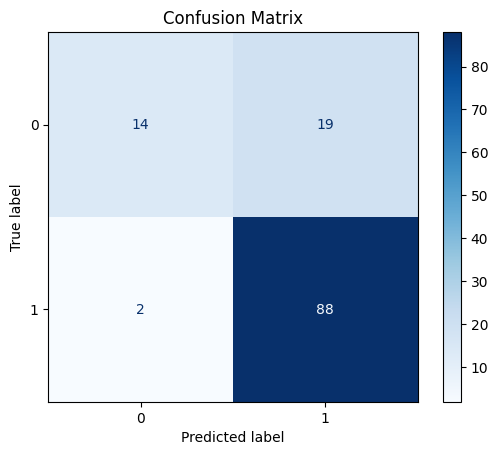

82.92682926829268
              precision    recall  f1-score   support

           0       0.88      0.42      0.57        33
           1       0.82      0.98      0.89        90

    accuracy                           0.83       123
   macro avg       0.85      0.70      0.73       123
weighted avg       0.84      0.83      0.81       123



In [13]:
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay,classification_report
c=confusion_matrix(y_test,y_pred)
print(c)
disp=ConfusionMatrixDisplay(c)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

acc=accuracy_score(y_test,y_pred)*100
print(acc)
print(classification_report(y_test,y_pred))

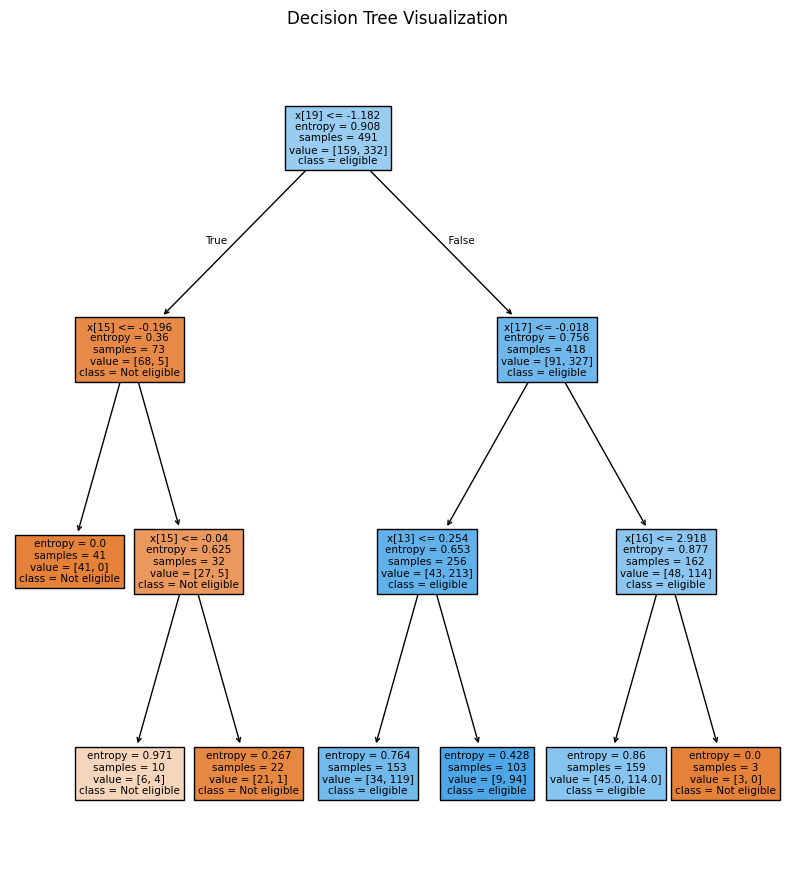

In [14]:
from sklearn import tree
plt.figure(figsize=(10, 11))
tree.plot_tree(d, filled=True,class_names=['Not eligible','eligible'])
plt.title("Decision Tree Visualization")
plt.show()